# Bit Rounding

[![Citation]](https://doi.org/10.1038/s43588-021-00156-2)

[Citation]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white

Bit Rounding is a filter that does not itself compress the data but reduces its precision to make it easier to compress.

Bit Rounding drops a set number of least-significant bits from the floating point mantissa, which often only contain incompressible noise / false information, by rounding in binary to a lower precision. The rounded number contains many trailing zero bits, which are highly compressible. Bit Rounding is typically followed by a lossy compressor, e.g. ZStandard or PCO.

The `BitRound` compressor is configured with `keepbits`, the number of bits in the mantissa to keep, which may be determined using Bit Information [^bitinformation].

[^bitinformation]: Klöwer, M., Razinger, M., Dominguez, J. J., Düben, P. D., & Palmer, T. N. (2021). Compressing atmospheric data into its real information content. *Nature Computational Science*, 1(11), 713–724. Available from: [doi:10.1038/s43588-021-00156-2](https://doi.org/10.1038/s43588-021-00156-2).

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `BitRound` compressor

In [4]:
from numcodecs_wasm_bit_round import BitRound

In [5]:
?BitRound

Init signature: BitRound(keepbits, _version='1.0.0')
Docstring:     
Codec providing floating-point bit rounding.

Drops the specified number of bits from the floating point mantissa,
leaving an array that is more amenable to compression. The number of
bits to keep should be determined by information analysis of the data
to be compressed.

The approach is based on the paper by Klöwer et al. 2021
(<https://www.nature.com/articles/s43588-021-00156-2>).

Parameters
----------
keepbits : ...
    The number of bits of the mantissa to keep.
    
    The valid range depends on the dtype of the input data.
    
    If keepbits is equal to the bitlength of the dtype's mantissa, no
    transformation is performed.
_version : ..., optional, default = "1.0.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
File:           ~/egu26-compression-sc2.5/.venv/lib/python3.13/site-packages/numcodecs_wasm_bit_round/__init__.py
Type:           ABCMeta
Subclasses:     

## Bounding the pointwise relative error

Bit Rounding can bound the relative error for not-subnormal floating-point numbers by translating the error bound into the `keepbits` parameter for a given data type using:

In [6]:
# From climatebenchpress.compressor
# Licensed under the Mozilla Public License 2.0
# By Tim Reichelt and Juniper Tyree
# https://github.com/ClimateBenchPress/compressor/blob/393c9168d86937b63e813d5bcf088b21902aa1bb/src/climatebenchpress/compressor/compressors/utils.py#L16-L39
def compute_keepbits(eb_rel: float, *, dtype: np.dtype) -> int:
    """
    Computes the number of mantissa bits to keep in order to satisfy a relative error bound.

    Parameters
    ----------
    eb_rel : float
        Pointwise relative error bound.
    dtype : numpy.dtype
        Data type of the input array.

    Returns
    -------
    int
        Number of mantissa bits to keep.
    """

    # - log2(rel_error) specifies the number of mantissa bits needed to satisfy
    # the rel_error bound (https://en.wikipedia.org/wiki/Machine_epsilon).
    # We need to round up to the nearest integer to ensure the error bound is not
    # exceeded.

    keepbits = -int(np.floor(np.log2(eb_rel)) - 1)

    # Ensure that keepbits is within the range of the mantissa bits of single precision.
    keepbits = max(min(keepbits, np.finfo(dtype).nmant), 0)

    return keepbits

In [7]:
BitRound(
    # 1% relative error bound for 32bit floats
    keepbits=compute_keepbits(0.01, dtype=np.float32),
)

BitRound(keepbits=8, _version='1.0.0')

## Bounding the pointwise absolute error

Bit Rounding can bound the absolute error by transforming the absolute error into a conservative error bound using:

```python
eb_rel = eb_abs / np.nanmax(np.abs(data))
```

## Preserving NaN Missing Values

NaN values are automatically preserved by Bit Rounding, though their exact bit patterns may change.

## Example

In [8]:
from numcodecs_combinators.stack import CodecStack
from numcodecs_wasm_zstd import Zstd

In [9]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [10]:
eb_rel = 0.01  # 1%

# stack Bit Rounding with ZStandard lossless compression
codec = CodecStack(
    BitRound(
        keepbits=compute_keepbits(eb_rel, dtype=da.dtype),
    ),
    Zstd(level=3),  # default ZStandard level
)

In [11]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

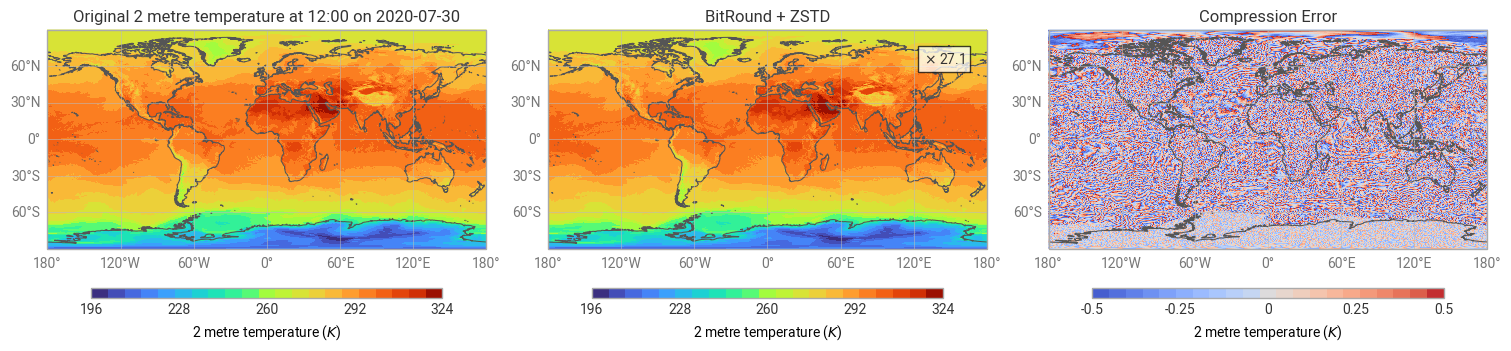

In [12]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title="BitRound + ZSTD",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()